 Praktikum 14 – Kubische Splines
Aufgabe 1 – Natürliche kubische Splineinterpolation

Gegeben ist die Funktion

$$
f(x)=\frac{1}{1+x^2}
$$

im Intervall ([-5,5]).

Für (n=6,;9,;15) werden äquidistant verteilte Punkte berechnet und mit natürlichen kubischen Splines interpoliert.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded


#GEGEBENE FUNTION!
def f(x):
    return 1 / (1 + x**2)

n_values = [6, 9, 15]   ## ANZAHL N, also 3 mal mit 6 9 und 15 punkten
x_fine = np.linspace(-5, 5, 1000) #intervall


#

plt.figure(figsize=(12, 8))




for idx, n in enumerate(n_values, 1): # alle prüfen gehen
    # 1. Stützpunkte definieren (n Punkte -> n-1 Intervalle)
    x = np.linspace(-5, 5, n)
    y = f(x)
    h = x[1] - x[0] # Äquidistanter Abstand
    
    # 2. Gleichungssystem für die inneren Momente aufbauen (N = n-2 innere Punkte)
    N_innere = n - 2
    
    # Tridiagonalmatrix für solve_banded (Zeile 0: oben, Zeile 1: Mitte, Zeile 2: unten)
    ab = np.zeros((3, N_innere))
    ab[0, 1:]  = 1.0   # Obere Nebendiagonale
    ab[1, :]   = 4.0   # Hauptdiagonale (laut Skript steht hier eine 4)
    ab[2, :-1] = 1.0   # Untere Nebendiagonale
    
    # 3. Rechte Seite 'b' berechnen (zentrale Differenzen der Funktionswerte)
    # y[2:] entspricht y_(i+1), y[1:-1] entspricht y_i, y[:-2] entspricht y_(i-1)
    b = (6.0 / h**2) * (y[2:] - 2 * y[1:-1] + y[:-2])
    
    # 4. System lösen, um die inneren Momente zu erhalten
    m_innere = solve_banded((1, 1), ab, b)
    
    # 5. Gesamten Momentenvektor inklusive der natürlichen Ränder (m_0 = m_(n-1) = 0) zusammensetzen
    m = np.zeros(n)
    m[1:-1] = m_innere
    
    # 6. Auswertung auf dem feinen Gitter (händische Spline-Auswertung nach Vorlesungsformel)
    y_spline = np.zeros_like(x_fine)
    for k in range(n - 1):
        # Maske für das aktuelle Intervall [x[k], x[k+1]]
        mask = (x_fine >= x[k]) & (x_fine <= x[k+1])
        if k == n - 2: # Für den allerletzten Punkt den Rand inkludieren
            mask = (x_fine >= x[k]) & (x_fine <= x[k+1] + 1e-5)
            
        xf_sub = x_fine[mask]
        
        # Die Auswertungsformel für das Intervall k aus dem Skript:
        A = (m[k] / (6 * h)) * (x[k+1] - xf_sub)**3
        B = (m[k+1] / (6 * h)) * (xf_sub - x[k])**3
        C = (y[k] / h - (h * m[k]) / 6) * (x[k+1] - xf_sub)
        D = (y[k+1] / h - (h * m[k+1]) / 6) * (xf_sub - x[k])
        
        y_spline[mask] = A + B + C + D

    # Plot
    plt.subplot(3, 1, idx)
    plt.plot(x_fine, f(x_fine), label='f(x)')
    plt.plot(x_fine, y_spline, '--', label='Händischer Spline S(x)')
    plt.plot(x, y, 'o', label='Stützpunkte')
    plt.title(f'Klassisch berechneter kubischer Spline mit n = {n}')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'f' is not defined

<Figure size 1200x800 with 0 Axes>

## Aufgabe 2 – Anwendung in der Robotersteuerung

Gegeben sind Zeit- und Positionswerte:

t = [0, 2, 4, 6, 8, 10, 12, 14, 16]

x = [-50, 200, 500, 750, 1000, 750, 500, 200, -50]

y = [200, 0, 250, 500, 250, 0, 250, 500, 200]
`

Zur Beschreibung der Bewegung werden zwei Splinefunktionen verwendet:

$$
S_x(t), \qquad S_y(t)
$$

Da Start- und Endpunkt identisch sind, eignet sich eine **periodische Randbedingung**, um eine glatte geschlossene Bewegungskurve zu erhalten.


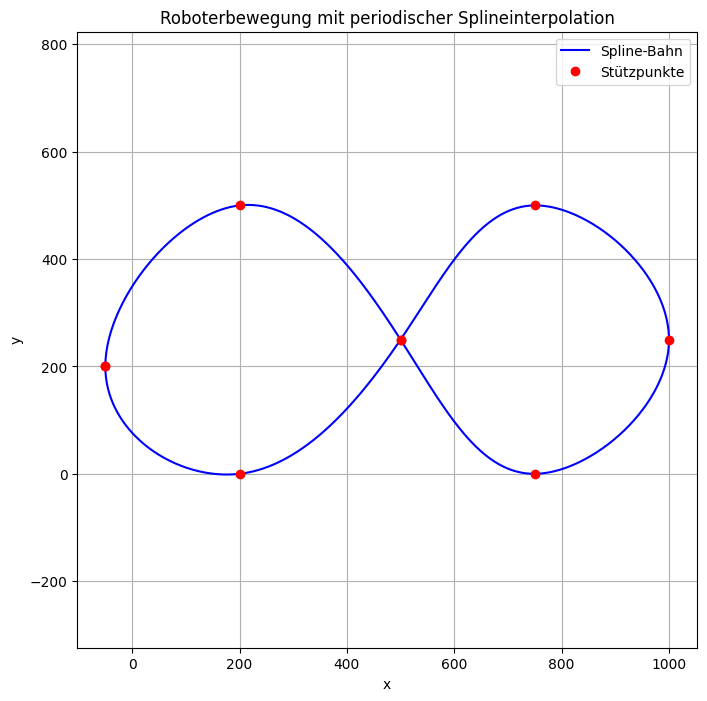

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Vorgabedaten
t = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16])
x = np.array([-50, 200, 500, 750, 1000, 750, 500, 200, -50])
y = np.array([200, 0, 250, 500, 250, 0, 250, 500, 200])

n = len(t)          
h = t[1] - t[0]     
N = n - 1           

# 1. Zyklische Gleichungsmatrix A aufbauen
A = np.zeros((N, N))
for i in range(N):
    A[i, i] = 4.0                       
    A[i, (i - 1) % N] = 1.0             
    A[i, (i + 1) % N] = 1.0             

# 2. Rechte Vektoren b_x und b_y bestimmen
b_x = np.zeros(N)
b_y = np.zeros(N)
for i in range(N):
    b_x[i] = (6.0 / h**2) * (x[(i + 1) % N] - 2 * x[i] + x[(i - 1) % N])
    b_y[i] = (6.0 / h**2) * (y[(i + 1) % N] - 2 * y[i] + y[(i - 1) % N])

# 3. Gleichungssysteme für die Momente lösen
m_x_indep = np.linalg.solve(A, b_x)
m_y_indep = np.linalg.solve(A, b_y)

# 4. Periodische Momentenvektoren komplettieren (m_last = m_first)
m_x = np.zeros(n)
m_x[:-1] = m_x_indep
m_x[-1] = m_x_indep[0]

m_y = np.zeros(n)
m_y[:-1] = m_y_indep
m_y[-1] = m_y_indep[0]

# 5. Auswertung auf feinem Zeitgitter per Schleife
t_fine = np.linspace(t[0], t[-1], 1000)
x_fine = np.zeros_like(t_fine)
y_fine = np.zeros_like(t_fine)

for k in range(n - 1):
    mask = (t_fine >= t[k]) & (t_fine <= t[k+1])
    if k == n - 2:
        mask = (t_fine >= t[k]) & (t_fine <= t[k+1] + 1e-5)
        
    tf_sub = t_fine[mask]
    
    # Interpolation für X-Werte
    Ax = (m_x[k] / (6 * h)) * (t[k+1] - tf_sub)**3
    Bx = (m_x[k+1] / (6 * h)) * (tf_sub - t[k])**3
    Cx = (x[k] / h - (h * m_x[k]) / 6) * (t[k+1] - tf_sub)
    Dx = (x[k+1] / h - (h * m_x[k+1]) / 6) * (tf_sub - t[k])
    x_fine[mask] = Ax + Bx + Cx + Dx
    
    # Interpolation für Y-Werte
    Ay = (m_y[k] / (6 * h)) * (t[k+1] - tf_sub)**3
    By = (m_y[k+1] / (6 * h)) * (tf_sub - t[k])**3
    Cy = (y[k] / h - (h * m_y[k]) / 6) * (t[k+1] - tf_sub)
    Dy = (y[k+1] / h - (h * m_y[k+1]) / 6) * (tf_sub - t[k])
    y_fine[mask] = Ay + By + Cy + Dy

# Plot
plt.figure(figsize=(8, 8))
plt.plot(x_fine, y_fine, 'b-', label='Spline-Bahn')
plt.plot(x, y, 'ro', label='Stützpunkte')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Roboterbewegung mit periodischer Splineinterpolation')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()